## Objective

Stock price forecasting is a complex research problem due to the variety of the factors influencing market trends. Traditionally, forecasting was conducted with strategies such as technical analysis, fundamental analysis and statistical models. However, over the years artificial intelligence have developed where algorithms have been trained to forecast the stock market using data such as historical data and technical indicators. Some of the most modern techniques include machine learning (ML), deep learning (DL) and reinforcement learning (RL).

In this project, our main objective will be to build a predictive model using a variety of machine learning models to analyse the historical data to predict trends and movements. Although using just historical data is not sufficient enough create a predictive model, the main objective is to demonstrate my data science skills involved with building a model. We will be going through the data and predictive analysis process which includes:
- Data Collection
- Data Cleaning and Preprocessing
- Exploratory Data Analysis
- Feature Engineering
- Model Selection and Training
- Model Evaluation
- Discussion and Conclusion

## Data Collection

We will be conducting this analysis on the the market index Standard and Poor's 500, or S&P 500. The S&P 500 is the market index tracking the stock performance of 500 leading companies listed on the New York Stock Exchange (NYSE) in the US. The data will be collected using Yahoo Finance from 1996 to the current period. This dataset includes the daily information of the index throughout the day. These include:
- Open
- High
- Low
- Close
- Volume

In [80]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [81]:
ticker = 'TSLA'

df = yf.download(ticker, start="2005-01-01", end="2018-01-01")
df = df.asfreq("B")

[*********************100%***********************]  1 of 1 completed


## Data Cleaning and Preprocessing

In [82]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500.0
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500.0
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000.0
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000.0
2010-07-05,NaN,NaN,NaN,NaN,NaN


In [83]:
df.columns = df.columns.droplevel(1)

In [84]:
df.index

DatetimeIndex(['2010-06-29', '2010-06-30', '2010-07-01', '2010-07-02',
               '2010-07-05', '2010-07-06', '2010-07-07', '2010-07-08',
               '2010-07-09', '2010-07-12',
               ...
               '2017-12-18', '2017-12-19', '2017-12-20', '2017-12-21',
               '2017-12-22', '2017-12-25', '2017-12-26', '2017-12-27',
               '2017-12-28', '2017-12-29'],
              dtype='datetime64[ns]', name='Date', length=1959, freq='B')

In [85]:
df['Close'] = df['Close'].ffill()
df['Volume'] = df['Volume'].ffill()

In [86]:
df = df.drop(['High', 'Low', 'Open'], axis=1)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1959 entries, 2010-06-29 to 2017-12-29
Freq: B
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1959 non-null   float64
 1   Volume  1959 non-null   float64
dtypes: float64(2)
memory usage: 45.9 KB


In [88]:
df.isna().sum()

Price
Close     0
Volume    0
dtype: int64

In [89]:
df.duplicated().sum()

np.int64(68)

In [90]:
df.describe()

Price,Close,Volume
count,1959.000000,1.959000e+03
mean,10.204248,6.745374e+07
std,7.218298,6.306284e+07
min,1.053333,1.777500e+06
25%,2.088000,1.967175e+07
50%,12.572667,5.418000e+07
75%,15.523000,8.996100e+07
max,25.666668,5.574585e+08


## Exploratory Data Analysis

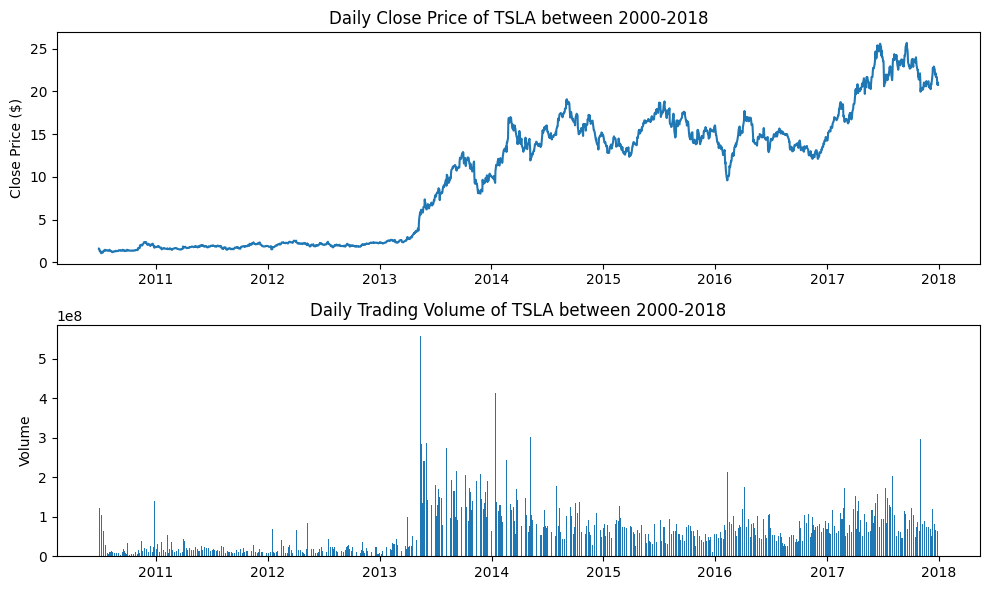

In [91]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot(df.index, df['Close'])
ax[0].set_title(f"Daily Close Price of {ticker} between 2000-2018")
ax[0].set_ylabel("Close Price ($)")

ax[1].bar(df.index, df['Volume'])
ax[1].set_title(f"Daily Trading Volume of {ticker} between 2000-2018")
ax[1].set_ylabel("Volume")

plt.tight_layout()
plt.show()

We can observe that there has been an upward trend in the closing pricing from 2000 till now, with the current closing pricing almost 5 times greater than at the beginning of the century.

## Feature Engineering

In addition to the closing price, we will also derive predictive features that may improve the predictive performance of our model.
These include:
- Moving Averages
- Lag Features
- Momentum and Rate of Change
- Rolling Statistics
- Volume-based Features

As most of these features uses the current Closing price in its calculations, we will shift the features one day such that they are calculating the previous days features to prevent data leakage.

#### Moving Averages and Return

In [92]:
df['MA_10'] = df['Close'].rolling(10).mean().shift(1)
df['MA_50'] = df['Close'].rolling(50).mean().shift(1)
df['Std_10'] = df['Close'].rolling(10).std().shift(1)
df['Std_50'] = df['Close'].rolling(50).std().shift(1)
df['LR'] = np.log(df['Close']/df['Close'].shift(1)).shift(1)

#### Lag Features

In [93]:
df['L1'] = df['Close'].shift(1)
df['L2'] = df['Close'].shift(2)
df['L7'] = df['Close'].shift(7)
df['L30'] = df['Close'].shift(30)

#### Momentum

In [94]:
df['Mmt_10'] = (df['Close'] - df['Close'].shift(10)).shift(1)
df['Mmt_Smth_5'] = df['Mmt_10'].rolling(5).mean().shift(1)

#### Volume

In [95]:
df['Vol_Ave_10'] = df['Volume'].rolling(10).mean().shift(1)
df['Vol_Ave_50'] = df['Volume'].rolling(50).mean().shift(1)
df['Vol_pct'] = df['Volume'].pct_change().shift(1)

#### Date

In [96]:
df['Day_of_Week'] = df.index.dayofweek
df['Month'] = df.index.month

In [97]:
df = df.iloc[365:]

## Model Selection and Training

For model selection and training, we will be evaluating the performance of the ARIMA model and the LSTM model. The metric that we will use to evaluate the model on is the root mean-squared error (RMSE). Additionally, during validation, the forecast for each day will be based on the true validation data instead of forecasting itervatively to avoid error accumulation and better trainig. Iterative forecasting will be conducted on the test data during model evaluation.

In [98]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [99]:
# Train-Val-Test Split
train = df.iloc[:int(0.8*len(df))]
val = df.iloc[int(0.8*len(df)):int(0.9*len(df))]
test = df.iloc[int(0.9*len(df)):]

In [100]:
val_error_dict = {}

### Classical Statistical Models

#### ARIMA

In [101]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import StandardScaler

Stationary Test

The ARIMA model assumes that our data is stationary. To assess stationarity, we will use the Augmented Dickey-Fuller (ADF) test which test the null hypothesis that the time series has a unit root (meaning it is non-stationary) against the alternate hypothesis that it is stationary.

In [102]:
def check_stationarity(time_series):
    result = adfuller(time_series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:",)
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    if result[1] < 0.05:
        print("Series is stationary")
    else:
        print("Series is not stationary")

print("Original Series")
check_stationarity(df['Close'])

temp_diff = df['Close'].diff().dropna()

print("\nFirst differenced series stationarity check")
check_stationarity(temp_diff)

Original Series
ADF Statistic: -1.196055154470778
p-value: 0.6752903785212327
Critical Values:
	1%: -3.434461656404719
	5%: -2.863356053770622
	10%: -2.567736831977157
Series is not stationary

First differenced series stationarity check
ADF Statistic: -38.83648579641388
p-value: 0.0
Critical Values:
	1%: -3.4344642432857992
	5%: -2.8633571955690647
	10%: -2.5677374399794197
Series is stationary


From this assessment, we can see that the orignal data is non-stationary. However, after we find the first difference, the series is found to be stationary.

Autocorrelation Analysis

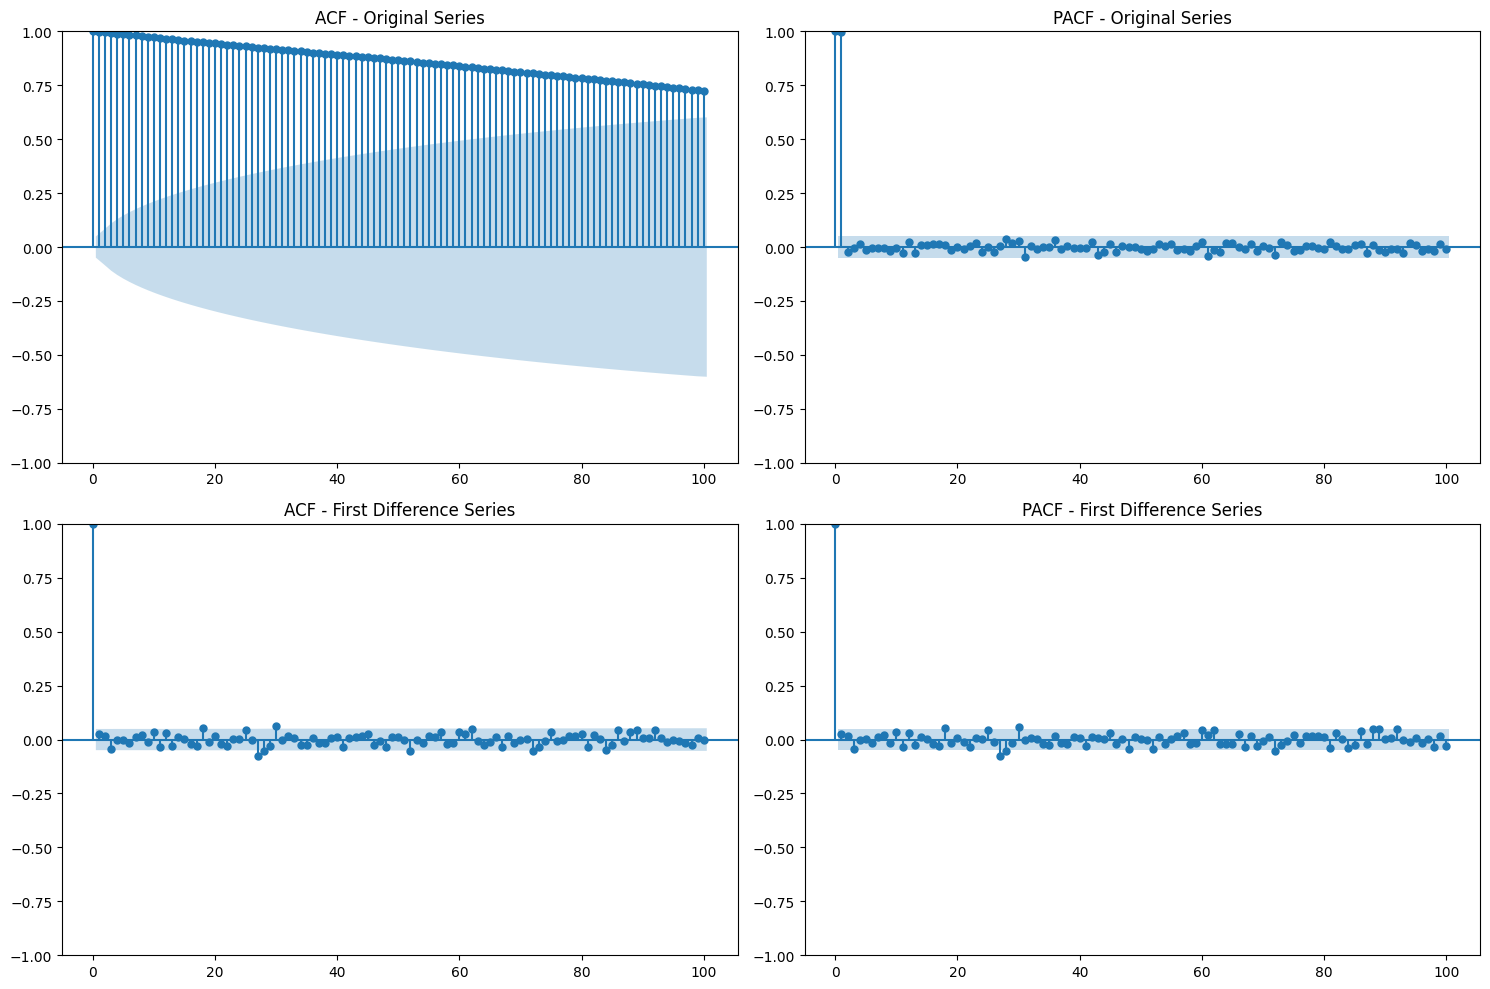

In [103]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

plot_acf(df['Close'], ax=ax[0, 0], lags = 100)
ax[0, 0].set_title("ACF - Original Series")

plot_pacf(df['Close'], ax=ax[0, 1], lags = 100)
ax[0, 1].set_title("PACF - Original Series")

plot_acf(temp_diff, ax=ax[1, 0], lags = 100)
ax[1, 0].set_title("ACF - First Difference Series")

plot_pacf(temp_diff, ax=ax[1, 1], lags = 100)
ax[1, 1].set_title("PACF - First Difference Series")

plt.tight_layout()
plt.show()

We can see that the ACF and PACF curves do not show much significant lags for both series. Since the ACF plot for the first difference series have an autocorrelation near zero and is stationary, the parameters that will be used for our ARIMA model is (0, 1, 0).

In [104]:
forecast_steps = 50

In [105]:
def arima_forecast(history):
    model = ARIMA(history, order=(0, 1, 0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    return yhat

history = [x for x in train['Close']]
predictions = list()
for t in range(forecast_steps):
    yhat = arima_forecast(history)
    predictions.append(yhat)

    obs = val['Close'].iloc[t]
    history.append(obs)

preds_df = pd.DataFrame(predictions, columns=['Close'])
preds_df.index = val.iloc[:forecast_steps].index

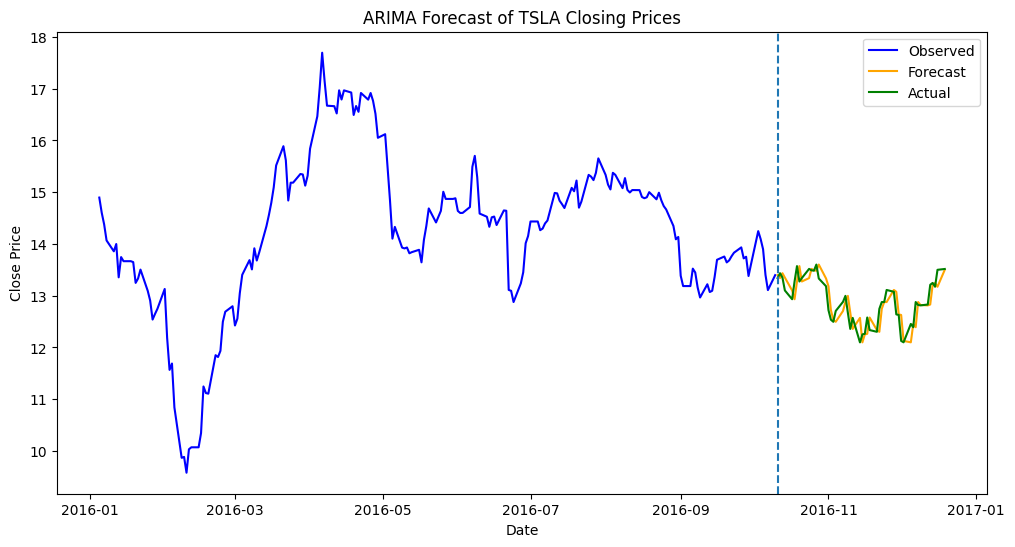

In [106]:
plt.figure(figsize=(12, 6))

plt.plot(train.tail(200)['Close'], label='Observed', color='blue')

plt.plot(preds_df.index, preds_df.iloc[:,0], label='Forecast', color='orange')

plt.plot(val.head(forecast_steps)['Close'], label='Actual', color='green')

plt.title(f'ARIMA Forecast of {ticker} Closing Prices')
plt.axvline(x=pd.to_datetime('2016-10-11'), linestyle='--')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [107]:
val_error = np.sqrt(mean_squared_error(preds_df.iloc[:, 0], val.iloc[:50, 0]))
val_error_dict['ARIMA'] = val_error
print("Validation Error:", val_error)

Validation Error: 0.24038750923830793


### Deep Learning Models

In [108]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [109]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [110]:
target = ['Close']

# Exogenous features that require scaling
scale_features = ['Volume', 'MA_10', 'MA_50', 'Std_10',
            'Std_50', 'LR', 'Mmt_10', 'Mmt_Smth_5', 'Vol_Ave_10', 'Vol_Ave_50',
            'Vol_pct', 'L1', 'L2', 'L7', 'L30']

# Exogenous features with no scaling
non_scale_features = ['Day_of_Week', 'Month']

# Split data into train-val-test
train_size = int(len(df) * 0.8)
val_size = int(len(df) * 0.1)

df_train = df[:train_size]
df_val = df[train_size:train_size + val_size]
df_test = df[train_size + val_size:]

train_scaled = df_train.copy()
val_scaled = df_val.copy()
test_scaled = df_test.copy()

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Split data into features and target
X_train, y_train = train_scaled.drop('Close', axis=1), train_scaled[['Close']]
X_val, y_val = val_scaled.drop('Close', axis=1), val_scaled[['Close']]
X_test, y_test = test_scaled.drop('Close', axis=1), test_scaled[['Close']]

# Apply scaling
X_train[scale_features] = scaler_X.fit_transform(X_train[scale_features])
y_train = scaler_y.fit_transform(y_train)

X_val[scale_features] = scaler_X.transform(X_val[scale_features])
y_val = scaler_y.transform(y_val)

X_test[scale_features] = scaler_X.transform(X_test[scale_features])
y_test = scaler_y.transform(y_test)

# Convert to tensors
X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32)

X_val = torch.tensor(np.array(X_val), dtype=torch.float32)
y_val = torch.tensor(np.array(y_val), dtype=torch.float32)

X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
y_test = torch.tensor(np.array(y_test), dtype=torch.float32)

In [111]:
class StockDataset(Dataset):
    def __init__(self, X, y, seq_len=10):
        self.X = X
        self.y = y
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx+self.seq_len]
        y_seq = self.y[idx+self.seq_len]
        return x_seq, y_seq

seq_len = 100

train_dataset = StockDataset(X_train, y_train, seq_len)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

val_dataset = StockDataset(X_val, y_val, seq_len)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = StockDataset(X_test, y_test, seq_len)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [112]:
class LSTMStock(nn.Module):
    def __init__(self, input_size, hidden_size=100, num_layers=3):
        super(LSTMStock, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=device)

        out, _ = self.lstm(x, (h0, c0))
        out =  self.fc(out[:, -1, :])
        return out

In [113]:
# Train LSTM model
exog_cols = scale_features + non_scale_features

input_size = len(exog_cols)
model = LSTMStock(input_size).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device).view(-1, 1)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

Epoch 10/200, Loss: 0.044244
Epoch 20/200, Loss: 0.006206
Epoch 30/200, Loss: 0.008389
Epoch 40/200, Loss: 0.006627
Epoch 50/200, Loss: 0.010483
Epoch 60/200, Loss: 0.007992
Epoch 70/200, Loss: 0.004029
Epoch 80/200, Loss: 0.009287
Epoch 90/200, Loss: 0.005335
Epoch 100/200, Loss: 0.007321
Epoch 110/200, Loss: 0.004633
Epoch 120/200, Loss: 0.002501
Epoch 130/200, Loss: 0.002203
Epoch 140/200, Loss: 0.003719
Epoch 150/200, Loss: 0.002885
Epoch 160/200, Loss: 0.002122
Epoch 170/200, Loss: 0.003504
Epoch 180/200, Loss: 0.001481
Epoch 190/200, Loss: 0.001574
Epoch 200/200, Loss: 0.005654


In [114]:
# Generate predictions
model.eval()
preds = []
history = X_train.unsqueeze(0)
for i in range(forecast_steps):
    with torch.no_grad():
        last_seq = history[-seq_len:]
        pred_scaled = model(last_seq)
        pred = scaler_y.inverse_transform(pred_scaled.numpy())

        preds.append(pred.item())

        next_seq = X_val[i].unsqueeze(0).unsqueeze(0)

        history = torch.cat([history, next_seq], dim=1)

In [115]:
# Convert predictions to a dataframe
preds_df = pd.DataFrame(
    preds, 
    columns=['Close'],
    index=df_val.iloc[:forecast_steps].index)

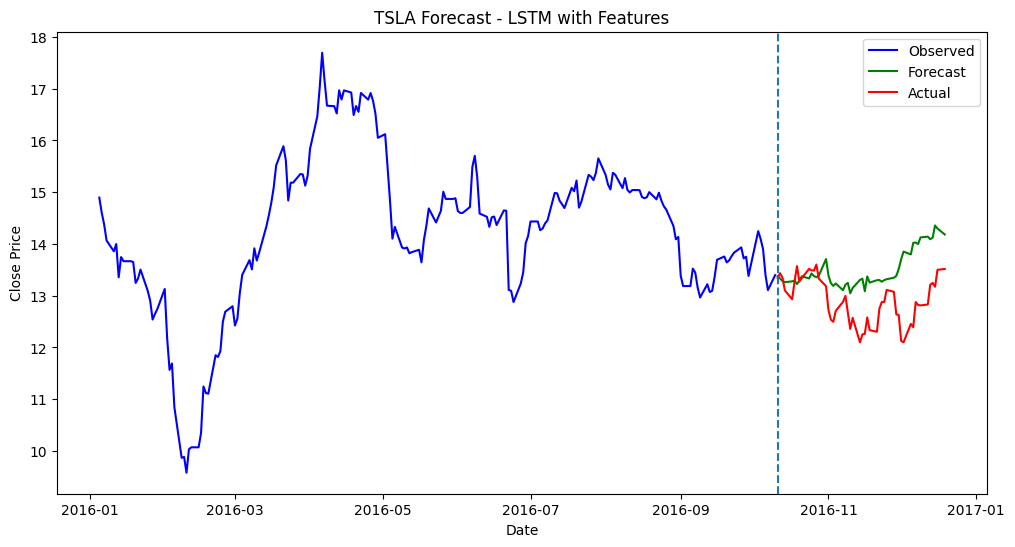

In [116]:
# Plot Forecast
plt.figure(figsize=(12, 6))

plt.plot(df_train.tail(200).index, df_train.tail(200)['Close'], label='Observed', color='blue')
plt.plot(preds_df.index, preds_df['Close'], label='Forecast', color='green')
plt.plot(df_val.head(forecast_steps).index, df_val.head(forecast_steps)['Close'], label='Actual', color='red')
plt.axvline(x=pd.to_datetime('2016-10-11'), linestyle='--')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title(f'{ticker} Forecast - LSTM with Features')
plt.legend()
plt.show()

In [117]:
# Calculate error
val_error = np.sqrt(mean_squared_error(df_val.head(forecast_steps)['Close'], preds_df['Close']))
val_error_dict['LSTM with Features'] = val_error

Based on this plot, although the forecast is able to somewhat follow the movements in the price. However, there are still quite a few gaps compared in the forecast, which may indicate that the model may have overfitted.

LSTM (Only Closing Price)

In [118]:
seq_length = 100

data = []

scaler = StandardScaler()

df['Close_scaled'] = scaler.fit_transform(df[['Close']])

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length-1])  
        y.append(data[i+seq_length-1])    
    return np.array(X), np.array(y)

train_data = df['Close_scaled'][:train_size]
val_data = df['Close_scaled'][train_size - seq_length + 1: train_size+val_size]
test_data = df['Close_scaled'][train_size+val_size - seq_length + 1:]

X_train, y_train = create_sequences(train_data.values, seq_length)
X_val, y_val = create_sequences(val_data.values, seq_length)
X_test, y_test = create_sequences(test_data.values, seq_length)


X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)

X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

y_train = y_train.view(-1, 1)
y_val = y_val.view(-1, 1)
y_test = y_test.view(-1, 1)

In [119]:
model = LSTMStock(input_size=1, hidden_size=32, num_layers=2).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [120]:
# Train LSTM model
def LSTM_train(X, y, model, loss, optimizer, epochs=200):
    model.train()
    for epoch in range(epochs):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.6f}")

In [121]:
LSTM_train(X_train, y_train, model, loss_fn, optimizer)

Epoch 10/200, Loss: 0.058327
Epoch 20/200, Loss: 0.029732
Epoch 30/200, Loss: 0.015292
Epoch 40/200, Loss: 0.009926
Epoch 50/200, Loss: 0.006686
Epoch 60/200, Loss: 0.005557
Epoch 70/200, Loss: 0.005325
Epoch 80/200, Loss: 0.005092
Epoch 90/200, Loss: 0.004928
Epoch 100/200, Loss: 0.004785
Epoch 110/200, Loss: 0.004651
Epoch 120/200, Loss: 0.004524
Epoch 130/200, Loss: 0.004396
Epoch 140/200, Loss: 0.004267
Epoch 150/200, Loss: 0.004135
Epoch 160/200, Loss: 0.003997
Epoch 170/200, Loss: 0.003851
Epoch 180/200, Loss: 0.003697
Epoch 190/200, Loss: 0.003546
Epoch 200/200, Loss: 0.003407


In [122]:
# Generate forecast
model.eval()

y_val_pred = model(X_val[:forecast_steps])
y_val_pred = scaler.inverse_transform(y_val_pred.detach().cpu().numpy())

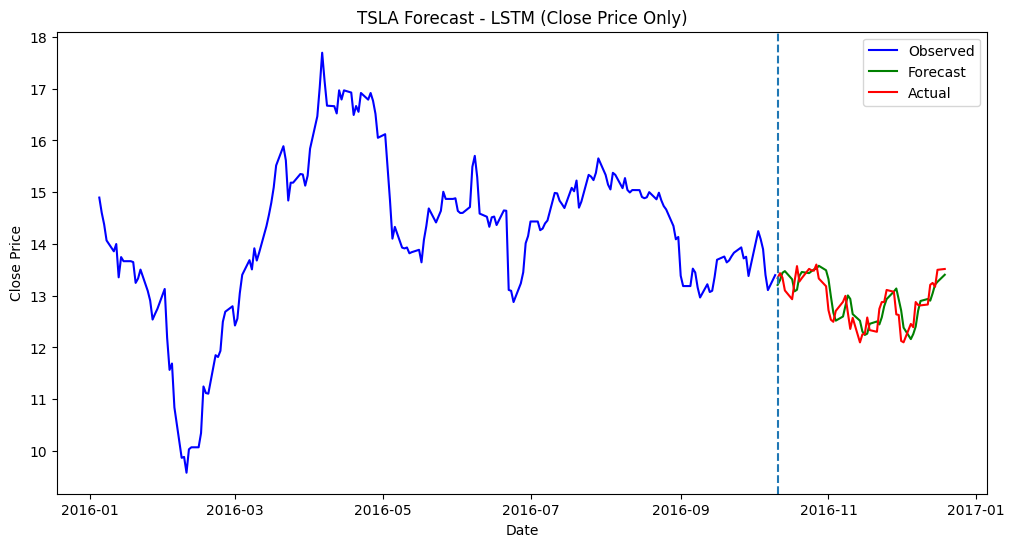

In [123]:
# Plot Forecast
plt.figure(figsize=(12, 6))

plt.plot(df_train.tail(200).index, df_train.tail(200)['Close'], label='Observed', color='blue')

plt.plot(df_val.iloc[:forecast_steps].index, y_val_pred, label='Forecast', color='green')
plt.plot(df_val.head(forecast_steps).index, df_val.head(forecast_steps)['Close'], label='Actual', color='red')
plt.axvline(x=pd.to_datetime('2016-10-11'), linestyle='--')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title(f'{ticker} Forecast - LSTM (Close Price Only)')
plt.legend()
plt.show()

In [124]:
# Calculate Error
val_error = np.sqrt(mean_squared_error(df_val.head(forecast_steps)['Close'], y_val_pred))
val_error_dict['LSTM (Close Price Only)'] = val_error
print("Validation Error:", val_error)

Validation Error: 0.277472305720227


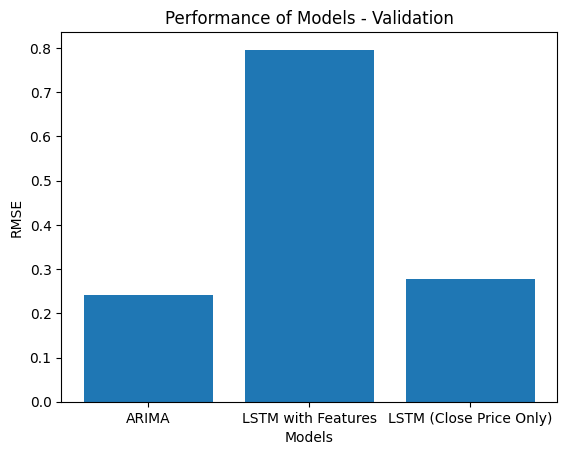

In [125]:
# Plot performances of models
plt.bar(val_error_dict.keys(), val_error_dict.values())
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.title('Performance of Models - Validation')
plt.show()

The ARIMA model has the lowest RMSE with the LSTM (Close Price Only) model closely following. The LSTM with features has a significaly higher RMSE compared to the others.

## Model Evaluation

In [126]:
test_error_dict = {}

ARIMA

In [127]:
train = pd.concat([train, val], axis=0)

In [128]:
history = [x for x in train['Close']]
predictions = []
for t in range(forecast_steps):
    yhat = arima_forecast(history)
    predictions.append(yhat)

    history.append(yhat)

preds_df = pd.DataFrame(predictions, columns=['Close'])
preds_df.index = test.iloc[:forecast_steps].index

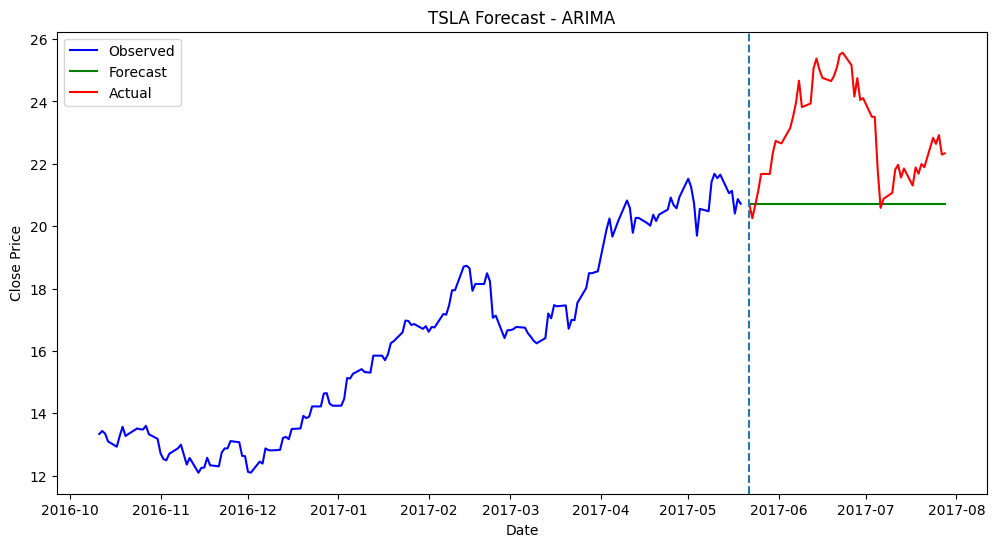

In [129]:
# Plot Forecast
plt.figure(figsize=(12, 6))
plt.plot(df_val.index, df_val['Close'], label='Observed', color='blue')

plt.plot(preds_df.index, preds_df, label='Forecast', color='green')
plt.plot(df_test.head(forecast_steps).index, df_test.head(forecast_steps)['Close'], label='Actual', color='red')
plt.axvline(x=pd.to_datetime('2017-5-22'), linestyle='--')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title(f'{ticker} Forecast - ARIMA')
plt.legend()
plt.show()

In [130]:
test_error = np.sqrt(mean_squared_error(preds_df, df_test.head(forecast_steps)['Close']))
test_error_dict['ARIMA'] = test_error

LSTM

In [131]:
# Combine train and validation set
X_train = torch.cat([X_train, X_val], dim=0)
y_train = torch.cat([y_train, y_val], dim=0)

In [132]:
# Create instance of LSTM, loss and optimizer
model = LSTMStock(input_size=1, hidden_size=32, num_layers=2).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [133]:
LSTM_train(X_train, y_train, model, loss_fn, optimizer)

Epoch 10/200, Loss: 0.044589
Epoch 20/200, Loss: 0.045973
Epoch 30/200, Loss: 0.018721
Epoch 40/200, Loss: 0.008417
Epoch 50/200, Loss: 0.005852
Epoch 60/200, Loss: 0.004953
Epoch 70/200, Loss: 0.004696
Epoch 80/200, Loss: 0.004584
Epoch 90/200, Loss: 0.004443
Epoch 100/200, Loss: 0.004335
Epoch 110/200, Loss: 0.004236
Epoch 120/200, Loss: 0.004139
Epoch 130/200, Loss: 0.004042
Epoch 140/200, Loss: 0.003945
Epoch 150/200, Loss: 0.003847
Epoch 160/200, Loss: 0.003748
Epoch 170/200, Loss: 0.003648
Epoch 180/200, Loss: 0.003549
Epoch 190/200, Loss: 0.003451
Epoch 200/200, Loss: 0.003356


In [134]:
# Generate Forecast
model.eval()

predictions = []
last_seq = X_train[-1].unsqueeze(0)
for i in range(forecast_steps):

    pred_scaled = model(last_seq)

    next_seq = torch.cat([last_seq[:, 1:, :], pred_scaled.unsqueeze(0)], dim=1)

    last_seq = next_seq

    pred = scaler.inverse_transform(pred_scaled.detach().cpu().numpy())

    predictions.append(pred[0][0])

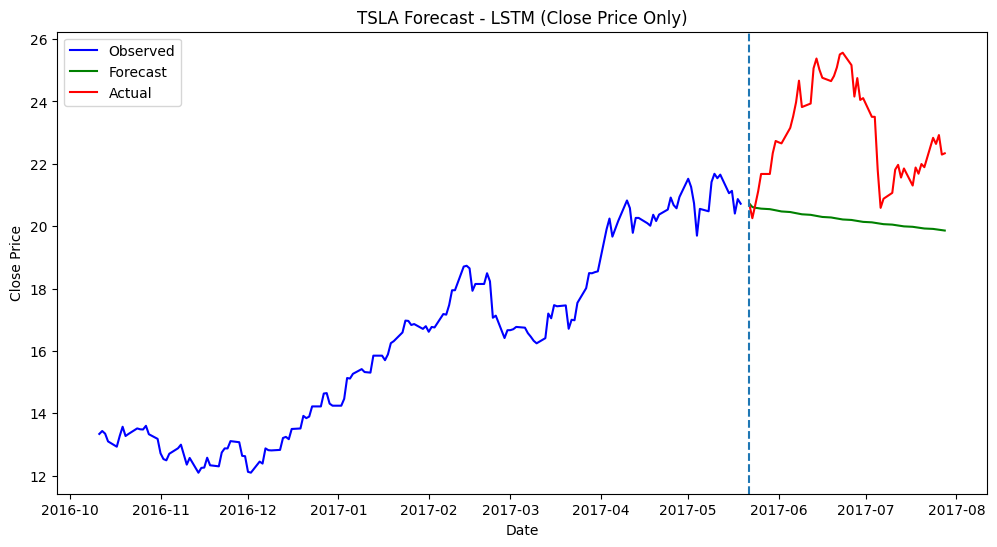

In [135]:
# Plot Forecast
plt.figure(figsize=(12, 6))
plt.plot(df_val.index, df_val['Close'], label='Observed', color='blue')

plt.plot(df_test.head(forecast_steps).index, predictions, label='Forecast', color='green')
plt.plot(df_test.head(forecast_steps).index, df_test.head(forecast_steps)['Close'], label='Actual', color='red')
plt.axvline(x=pd.to_datetime('2017-5-22'), linestyle='--')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title(f'{ticker} Forecast - LSTM (Close Price Only)')
plt.legend()
plt.show()

In [136]:
test_error = np.sqrt(mean_squared_error(predictions, df_test.head(forecast_steps)['Close']))
test_error_dict['LSTM (Close Price Only)'] = test_error

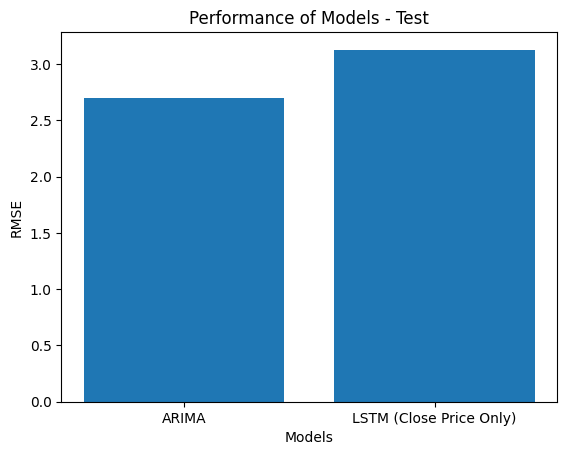

In [137]:
# Plot performances of models
plt.bar(test_error_dict.keys(), test_error_dict.values())
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.title('Performance of Models - Test')
plt.show()

## Discussion and Conclusion

Based on the model training and evaluation, the model that was determined to perform the best is the ARIMA model with parameters (0, 1, 0) with no exogenous features. This model is essentially the first time difference of the prices and a random walk, which indicates that the model was unable to learn the non-linear relationships of the data. The LSTM model with only the closing prices of the past 100 days had a similar performance. This model seems to perform well as it is able to capture the long term dependencies with the LSTM architecture. The LSTM model with the features had the worse performance, which was significantly higher than the other models. This indicates that either the model was unable to learn the non-linear relationships between the features and the target or that the features were processed incorrectly.

As stock prices are essentially random walks (non-stationary) and generally noisy, it is quite difficult to forecast in the short-term. Therefore, it is more appropriate to forecast the trend in the movements with the assumption of the current environment and knowledge. As assessed in model evaluation on the test error and forecasting iteratively instead of the validation values, both models perform significantly worse. The ARIMA model essentially forecasts the last known value due to the parameters (0, 1, 0) being a random walk. On the other hand, the LSTM model forecasts a downward trend which somewhat follows the trend of the last known prices but was unable to learn of the overall long-term upward trend. Although the RMSE can be a good metric to assess the performance of models, it should not be the only indication. Assessing the overall trend is a much more appropriate measure of performance.

This project is an introductory demonstration of how data science and machine learning can be used to forecast time series data like the stock market. The following points are some suggestions that can be implemented to improve the models:
- ARIMA - Include exogenous features
- LSTM - Forecast multiple time steps at a time instead of just the next day. This allows the model to learn temporal consistencies.
- Hyperparameter Tuning
- Exogenous Features - Understand which features are significant